In [1]:
# Importing libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [2]:
df.pivot_table(values='salary_year_avg', index='job_country',columns='job_title_short' ,aggfunc='mean')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.000000,NaN,69981.250000,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.000000,45000.000000,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.000000,197500.0,85436.375000,94276.846154,99536.916667,131009.666667,NaN,147500.0,NaN,174500.000000
Armenia,NaN,NaN,100500.000000,48750.000000,NaN,87021.000000,NaN,NaN,NaN,NaN
Australia,87666.666667,110000.0,102875.000000,112479.983333,139755.857143,122304.142857,50640.0,119894.0,157500.0,140655.833333
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.000000,NaN,NaN,50000.000000,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.000000,NaN,NaN,NaN,NaN,NaN
Vietnam,74400.000000,NaN,90842.454545,98508.187500,89066.666667,71381.250000,100512.5,127125.0,79200.0,53600.000000


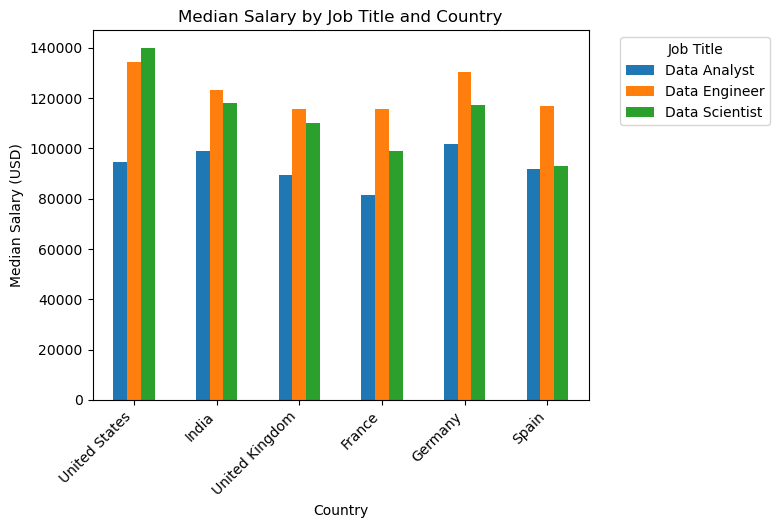

In [28]:
top_countries = df['job_country'].value_counts().head(6).index

df_job_country_salary = df.pivot_table(
    values='salary_year_avg', 
    index='job_country',
    columns='job_title_short',
    aggfunc='mean')

df_job_country_salary = df_job_country_salary.loc[top_countries]

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_job_country_salary = df_job_country_salary[job_titles]

df_job_country_salary.plot(kind='bar')
plt.title('Median Salary by Job Title and Country')
plt.xlabel('Country')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Median Salary (USD)')
plt.legend(title='Job Title', loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()